In [1]:
%matplotlib widget
import sys
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from importlib import reload

src = str(Path('../src').resolve())
if src not in sys.path:
    sys.path.append(src)

from evaluate import *

In [2]:
fig_dir = Path("../runs/lstm_mlp/_figures")
exp_dict = {
    'All Data': Path("../runs/lstm_mlp/all_data_20241105_180934"),
    'ERA5 & Landsat': Path("../runs/lstm_mlp/no_static_20241105_181727"),
    'ERA5 & Static': Path("../runs/lstm_mlp/no_landsat_20241105_180933"),
    'ERA5 only': Path("../runs/lstm_mlp/era5_only_20241105_181954"),
    'Landsat & Static': Path("../runs/lstm_mlp/no_era5_20241105_180935"),
    'Landsat only': Path("../runs/lstm_mlp/landsat_only_20241105_182010")
}

# Define colors and styles
both_color = '#d95f02'
ls_color = '#1b9e77'
e5_color = '#7570b3'
line_styles = [
    (both_color,'-'),
    (both_color,'--'),
    (e5_color,'-'),
    (e5_color,'--'),
    (ls_color,'-'),
    (ls_color,'--')
]
# Create custom legend elements
legend_elements = [
    mp.lines.Line2D([0], [0], color=both_color, lw=2, label='ERA5 & Landsat'),
    mp.lines.Line2D([0], [0], color=e5_color, lw=2, label='ERA5'),
    mp.lines.Line2D([0], [0], color=ls_color, lw=2, label='Landsat'),
    mp.lines.Line2D([0], [0], color=None, lw=0, label=''),
    mp.lines.Line2D([0], [0], color='black', lw=2, linestyle='-', label='With Static'),
    mp.lines.Line2D([0], [0], color='black', lw=2, linestyle='--', label='Without Static')
]           

exp_names = []
results = []
bulk_metrics = []
basin_metrics = []
predict_results = []
for exp_name, exp_dir in exp_dict.items():
    exp_names.append(exp_name)
    with open(exp_dir / "test_data.pkl", 'rb') as f:
        r, bulk_m, basin_m = pickle.load(f)
        
        # for feat in ['usgs_q']:
        for feat in ['ssc','flux','usgs_q']:
            lt10 = basin_m[feat]['num_obs'] < 10
            basin_m.loc[lt10, feat] = np.nan
        
        results.append(r)
        bulk_metrics.append(bulk_m)
        basin_metrics.append(basin_m)
        
    # with open(exp_dir / "predict_data.pkl", 'rb') as f:
    #     predict_results.append(pickle.load(f))

        
fig_dir.mkdir(exist_ok=True, parents=True)

In [6]:
bulk_metrics[0]

{'ssc': {'num_obs': np.int64(30520),
  'R2': 0.4475501775741577,
  'MAPE': np.float64(65.18133453421979),
  'nBias': np.float32(-2.4874876),
  'RE': np.float32(48.99981),
  'RB': np.float32(-2.5509477),
  'qRE': array([ 20.34781194,  48.99981261, 104.49469181]),
  'qnBias': array([-34.71821547,  -2.48748753,  44.92940158]),
  'MAE': np.float32(147.34843),
  'RMSE': np.float32(948.4814),
  'rRMSE': np.float32(431.9004),
  'KGE': np.float64(0.5834089489091158),
  'NSE': np.float32(0.088157535),
  'Agreement': np.float32(0.65615344)},
 'flux': {'num_obs': np.int64(15650),
  'R2': 0.5812610387802124,
  'MAPE': np.float64(102.31153030393372),
  'nBias': np.float32(2.6496608),
  'RE': np.float32(57.197308),
  'RB': np.float32(2.649653),
  'qRE': array([ 23.00057553,  57.19730856, 128.38640233]),
  'qnBias': array([-35.31631455,   2.64966069,  59.21774954]),
  'MAE': np.float32(21093.61),
  'RMSE': np.float32(94798.06),
  'rRMSE': np.float32(267.8064),
  'KGE': np.float64(0.6665966791960136),

In [4]:
bulk_metrics[4]['ssc']

{'num_obs': np.int64(30520),
 'R2': 0.11070597171783447,
 'MAPE': np.float64(114.19423490564351),
 'nBias': np.float32(-2.3710365),
 'RE': np.float32(75.57197),
 'RB': np.float32(-2.428615),
 'qRE': array([ 28.77678658,  75.57195757, 184.73675888]),
 'qnBias': array([-44.43591386,  -2.37103673,  71.09942734]),
 'MAE': np.float32(187.48248),
 'RMSE': np.float32(1203.3864),
 'rRMSE': np.float32(896.9974),
 'KGE': np.float64(-0.08488160354230612),
 'NSE': np.float32(-11.548704),
 'Agreement': np.float32(0.17656976)}

In [23]:
# MONTHLY KGE

import evaluate 

feature = 'flux'

# Group by basin and month, then calculate the mean for predicted and observed discharge
daily_df = results[0].copy()
daily_df = daily_df[~daily_df['obs'][feature].isna()]
daily_df['yyyy-mm'] = daily_df.index.get_level_values('date').to_period('M')
monthly_avg = daily_df.groupby(['basin', 'yyyy-mm']).mean()

# Drop NaNs to prevent issues in the KGE calculation
monthly_avg = monthly_avg.dropna()

# Apply KGE calculation per basin
kge_results = monthly_avg.groupby('basin').apply(
    lambda group: evaluate.metrics.calc_kge(group['obs'][feature], group['pred'][feature])
)

# Convert to a DataFrame for better readability
kge_results = kge_results.rename('KGE')
(kge_results>0.6).mean()

np.float64(0.3717948717948718)

In [15]:
kge_results.median()

np.float64(0.49404608436486985)

In [5]:
kge_results.mean()

np.float64(-0.7227802814161287)

In [5]:
cohen_q = [0.48, 0.49, 0.51, 0.18, 0.48, 0.30, 0.18, 0.34, 0.53, 0.25]
cohen_s = [0.64, 0.36, 0.39, 0.68, 0.38, 0.21, 0.35, 0.3, 0.14, 0.12, 0.67, 0.50, 0.17]

np.median(cohen_s)

np.float64(0.36)

In [19]:

li_q = [0.81, 0.82, 0.82, 0.36, 0.19, 0.11, 0.71, 0.76, 0.64, 0.64,
        0.55, 0.81, 0.51, 0.39, 0.35, 0.71, 0.57, 0.50, 0.59, 0.69,
        0.56, 0.15, 0.75, 0.67, 0.48, 0.38, 0.63, 0.49, 0.37, 0.33, 
        0.29, 0.67, -0.04, 0.84, 0.51]

li_s = [0.45, 0.46, 0.47, 0.62, 0.50, -0.92, -0.69, -14.83, 0.35, -3.51,
        0.54, 0.52, -0.34, 0.46, -0.35, -22.33, -2.25, 0.07, 0.58, 0.01,
        -232.26, -6.91, -33.69, 0.27, 0.28, -0.25, 0.15, 0.33, -0.26, -0.25,
        0.28, -0.30, 0.33, -0.43, -0.16]

print(np.median(li_q))
print(np.median(li_s))

0.56
0.01


In [ ]:
import sklearn.metrics as skm
from evaluate.metrics import mask_nan
from scipy.optimize import curve_fit


def get_r2(df, v):
    x = df['obs'][v]
    y = df['pred'][v]  
    r2 = mask_nan(skm.r2_score)(x, y)
    return r2


def get_log_r2(df, v):
    x = np.log10(df['obs'][v])
    y = np.log10(df['pred'][v])
    log_r2 = mask_nan(skm.r2_score)(x, y)
    return log_r2

print('Median basin scores')
for var in ['ssc','flux','usgs_q']:
    r2 = results[0].groupby('basin').apply(get_r2, var).median()
    log_r2 = results[0].groupby('basin').apply(get_log_r2, var).median()
    print(f'{var}:\tr2:{r2}\tlog r2:{log_r2}')
    
print('Bulk scores')
for var in ['ssc','flux','usgs_q']:
    r2 = get_r2(results[0], var)
    log_r2 = get_log_r2(results[0], var)
    print(f'{var}:\tr2:{r2}\tlog r2:{log_r2}')

Median basin scores
ssc:	r2:0.2678389549255371	log r2:0.529705822467804
flux:	r2:0.4770748019218445	log r2:0.7997424900531769
usgs_q:	r2:0.42759454250335693	log r2:0.5435986518859863
Bulk scores
ssc:	r2:0.4475501775741577	log r2:0.8347311019897461
flux:	r2:0.5812610387802124	log r2:0.9278162717819214
usgs_q:	r2:0.809273898601532	log r2:0.853654682636261


In [12]:
basin_metrics[0]['usgs_q']['NSE'].median()

np.float64(0.38964128494262695)

In [ ]:
results[0].index.get_level_values('basin').unique()

In [ ]:
results[0]

In [ ]:
x = m[feature, metric].astype(float)
x

In [ ]:
# dt_mask = (results[0]['dt']>=365).any(axis=1)

# sat_results = results[0][dt_mask].copy()
# nosat_results = results[1][dt_mask.reindex(results[1].index).fillna(False)].copy()

# sat_bulk_metrics = get_all_metrics(sat_results)
# sat_basin_metrics = get_basin_metrics(sat_results)

# nosat_bulk_metrics = get_all_metrics(nosat_results)
# nosat_basin_metrics = get_basin_metrics(nosat_results)

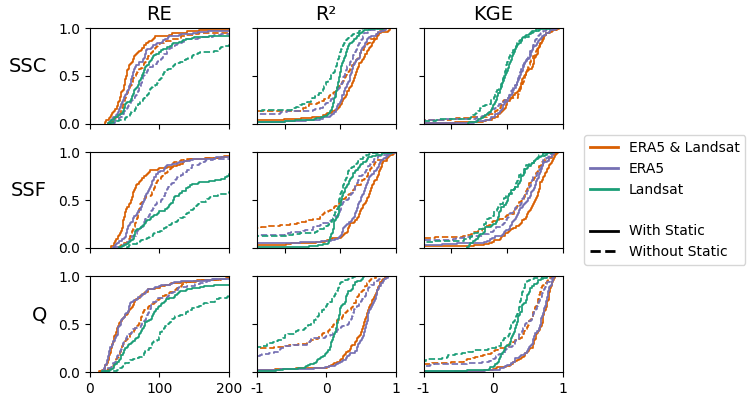

In [88]:
plt.close('all')

metric_args = {
    'RE':{'range':[0,200]},
    'R2': {'range':[-1.5,1]},
    'KGE': {'range':[-1.5,1]}
    }

feature_labels = ['SSC', 'SSF', 'Q']
features = ['ssc', 'flux', 'usgs_q']
nRows = len(features)
nCols = len(metric_args)
fig, axes = plt.subplots(nRows, nCols, figsize=(7.5, 4))

for feature, axes_row in zip(features, axes):
    for (metric, metric_kwargs), ax in zip(metric_args.items(), axes_row):
        for m, (c, s) in zip(basin_metrics, line_styles):
            if (feature, metric) not in m:
                continue
            x = m[feature, metric].astype(float)
            x = x[np.isfinite(x)]
            
            if 'rb' in metric.lower():
                x = np.abs(x)
                
            ax.ecdf(x, color=c, linestyle=s, linewidth=1.25)
        
        # ax.set_aspect(1./ax.get_data_ratio())
        ax.set_xlim(metric_kwargs['range'])
        ax.set_ylim([0,1])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
# Top Axes
for metric, ax in zip(['RE','R²','KGE'], axes[0,:]):
    ax.set_title(metric, fontsize=14)
    
# Bottom Axes
for ax in axes[-1,:]:
    ax.set_xticks(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 3))
    ax.set_xticklabels([int(label) for label in np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 3)])
    
# Left Axes
for label, ax in zip(feature_labels, axes[:,0]):
    ax.set_ylabel(label, rotation=0, ha='right', fontsize=14, labelpad=8)
    ax.set_yticks(np.linspace(0, 1, 3))
    ax.set_yticklabels([f"{lab:0.1f}" for lab in np.linspace(0, 1, 3)])
    

# Adjust spacing to make room for the legend
plt.subplots_adjust(top=0.93, bottom=0.07, left=0.12, right=0.75, wspace=0.2, hspace=0.3)

fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.77, 0.5))


# fig.tight_layout()
plt.show()

fig.savefig(fig_dir / "ablation_cdfs.png",  dpi=300)

In [40]:
plt.subplots_adjust(top=0.93, bottom=0.07, left=0.15, right=0.8, wspace=0.3)

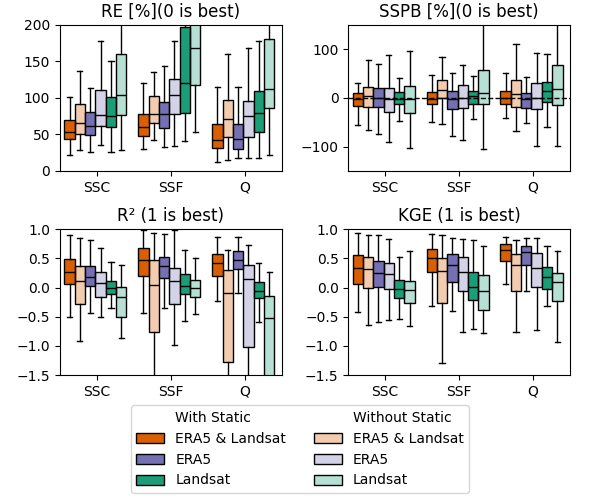

In [67]:
plt.close('all')
num_models = len(results)
target_variables = ['ssc','flux','usgs_q']
num_targets = len(target_variables)

colors = [t[0] for t in line_styles]
lines = [t[1] for t in line_styles]
face_colors = [c + ('' if l=='-' else '50') for c, l in zip(colors,lines)]

# Box width and spacing adjustments
box_width = 0.14
offset = box_width * (num_models / 2)

metric_names = {'RE':'RE [%](0 is best)', 
                'RB':'SSPB [%](0 is best)',
                'R2': 'R² (1 is best)',
                'KGE': 'KGE (1 is best)'}

n_metrics = len(metric_names)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 5))
axes= axes.flatten()

for ax, (mkey, mname) in zip(axes, metric_names.items()):
    for j, var in enumerate(target_variables):
        positions = np.array([j + (i - num_models / 2 + 0.35) * box_width for i in range(num_models)])
        box_data = [np.array(m[var][mkey], dtype=float) for m in basin_metrics]
        
        box_data = [x[~np.isnan(x)] for x in box_data]

        box = ax.boxplot(box_data, positions=positions, widths=box_width,
                         patch_artist=True, medianprops={'color':'black'}, showfliers=False)
        
        for patch, face_color in zip(box['boxes'], face_colors):
            patch.set_facecolor(face_color)
            
        ax.set_title(mname)

    ax.set_xticks(np.arange(num_targets))
    ax.set_xticklabels(['SSC','SSF','Q'])
    ax.set_xlim([-0.5, 2.5])
    

# Modify axes, legends, etc. as needed
axes[0].set_ylim([0, 200])

axes[1].plot([-1, 3], [0, 0], 'k', linestyle='--', linewidth=1, zorder=10)
axes[1].set_ylim([-150, 150])

# axes[2].plot([-1, 3], [0, 0], 'k', linestyle='--', linewidth=1, zorder=10)
axes[2].set_ylim([-1.5, 1])

axes[3].set_ylim([-1.5, 1])


# Create custom legend elements
legend_elements = [
    mp.patches.Patch(facecolor='none', edgecolor='none', label='With Static'), # Title 1
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[0], ec='black', label='ERA5 & Landsat'),
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[2], ec='black', label='ERA5'),
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[4], ec='black', label='Landsat'),
    mp.patches.Patch(facecolor='none', edgecolor='none', label='Without Static'), # Title 2
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[1], ec='black', label='ERA5 & Landsat'),
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[3], ec='black', label='ERA5'),
    mp.patches.Rectangle((0, 0), 1, 1, color=face_colors[5], ec='black', label='Landsat'),
]

fig.subplots_adjust(left=0.1, right=0.95, bottom=0.25, top=0.95, wspace=0.3, hspace=0.4)
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=True)

plt.show()

fig.savefig(fig_dir / f"basin_boxplots_zoom.png", dpi=300)


In [46]:
bulk_metrics[0]

{'ssc': {'num_obs': np.int64(30520),
  'R2': 0.4475501775741577,
  'MAPE': np.float64(65.18133453421979),
  'nBias': np.float32(-2.4874876),
  'RE': np.float32(48.99981),
  'RB': np.float32(-2.5509477),
  'qRE': array([ 20.34781194,  48.99981261, 104.49469181]),
  'qnBias': array([-34.71821547,  -2.48748753,  44.92940158]),
  'MAE': np.float32(147.34843),
  'RMSE': np.float32(948.4814),
  'rRMSE': np.float32(431.9004),
  'KGE': np.float64(0.5834089489091158),
  'NSE': np.float32(0.088157535),
  'Agreement': np.float32(0.65615344)},
 'flux': {'num_obs': np.int64(15650),
  'R2': 0.5812610387802124,
  'MAPE': np.float64(102.31153030393372),
  'nBias': np.float32(2.6496608),
  'RE': np.float32(57.197308),
  'RB': np.float32(2.649653),
  'qRE': array([ 23.00057553,  57.19730856, 128.38640233]),
  'qnBias': array([-35.31631455,   2.64966069,  59.21774954]),
  'MAE': np.float32(21093.61),
  'RMSE': np.float32(94798.06),
  'rRMSE': np.float32(267.8064),
  'KGE': np.float64(0.6665966791960136),

In [18]:
obs = basin_metrics[2]['flux']['num_obs'] > 50
r2 = basin_metrics[2]['flux']['R2'] > 0
kge = basin_metrics[0]['flux']['KGE']> 0.3
nse = basin_metrics[0]['usgs_q']['NSE']> 0.20
mask = obs & r2 & kge# & nse

bias_change = np.abs(basin_metrics[2]['flux']['nBias']) - np.abs(basin_metrics[0]['flux']['nBias'])
basin = bias_change[mask].idxmax()
# basin_metrics[0].loc[basin]

In [19]:
obs = basin_metrics[0]['flux']['num_obs'] > 100
r2 = basin_metrics[0]['flux']['R2'] > 0
kge = basin_metrics[0]['flux']['KGE']> 0
nse = basin_metrics[0]['usgs_q']['NSE']> 0
mask = obs & r2 & kge & nse
print(sum(mask))

basin = basin_metrics[0][mask].sample(1).index[0]
print(basin)
# basin_metrics[0].loc[basin]

print(basin_metrics[0].loc[basin,('flux','RB')])
print(basin_metrics[2].loc[basin,('flux','RB')])

32
USGS-05481650
-13.553739
-25.972866


NameError: name 'date' is not defined

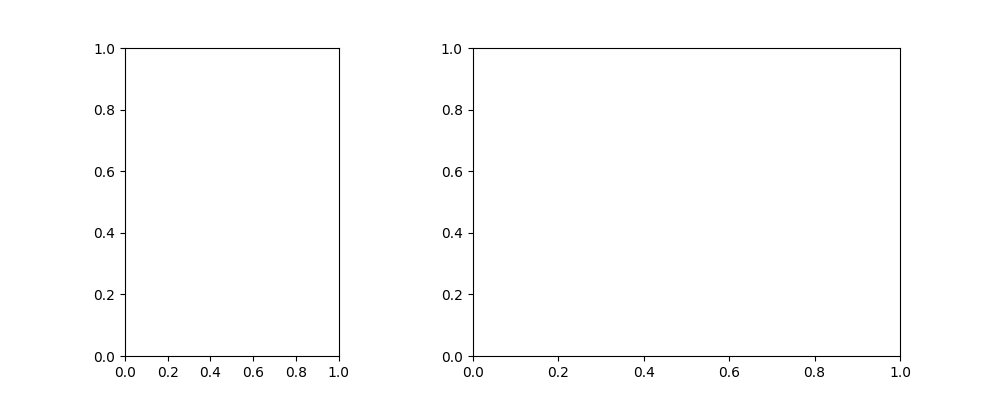

In [17]:
import matplotlib.gridspec as gridspec

"""
USGS-12510500 good improvement in bias.
"""

# Plot the true values and predictions
plt.close('all')

# Create a figure
fig = plt.figure(figsize=(10, 4))

# Create a GridSpec with 1 row and 3 columns
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.2, 2])
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 2])]

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

legend_elements = []
mins, maxs = [], []
for preds, name, (c, s) in zip(predict_results, exp_names, line_styles):
    if s == '--':
        continue
    
    basin_mask  = preds.index.get_level_values('basin') == basin
    sorted_df = preds[basin_mask].sort_values('date')
    
    date = sorted_df.index.get_level_values('date')
    values = sorted_df['pred']['flux'].values
    obs = sorted_df['obs']['flux'].values
     
    if not 'era5' in preds['dt'].columns:
        #Remove the predictions with no query basis
        mask = sorted_df['dt']['landsat'] == 0
        masked_date = date[mask]
        masked_values = values[mask]
        masked_obs = obs[mask]
        axes[0].scatter(masked_obs, masked_values, marker='.',color=c)
        l = axes[1].scatter(masked_date, masked_values, 15, marker='s', color=c, label=name)#, facecolor='none')
        l = axes[1].plot(date, values, linewidth=1, color=c, label=name)#, facecolor='none')
    else:
        axes[0].scatter(obs, values, marker='.',color=c)
        l = axes[1].plot(date, values, color=c, label=name)
    
    legend_elements.append(l)
        
    mins.extend([np.nanmin(values), np.nanmin(obs)])
    maxs.extend([np.nanmax(values), np.nanmax(obs)])
    
    
axes[1].scatter(date, obs, zorder=10, color='k')

min_val = float(np.min(mins))*0.9
max_val = float(np.max(maxs))*1.1
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--')

# Setting axes to be square and equal range
axes[0].axis('square')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].set_xlabel(f"Observed Flux")
axes[0].set_ylabel(f"Predicted Flux")
axes[0].set_title(f"Basin: {basin}")

# axes[1].set_yscale('log')

fig.subplots_adjust(top=0.85, left=0.05, right=0.95, wspace=0.05, hspace=0.4)
fig.autofmt_xdate()

plt.show()

# fig.savefig(fig_dir / f"{basin}_timeseries.png",  dpi=300)

NameError: name 'date' is not defined

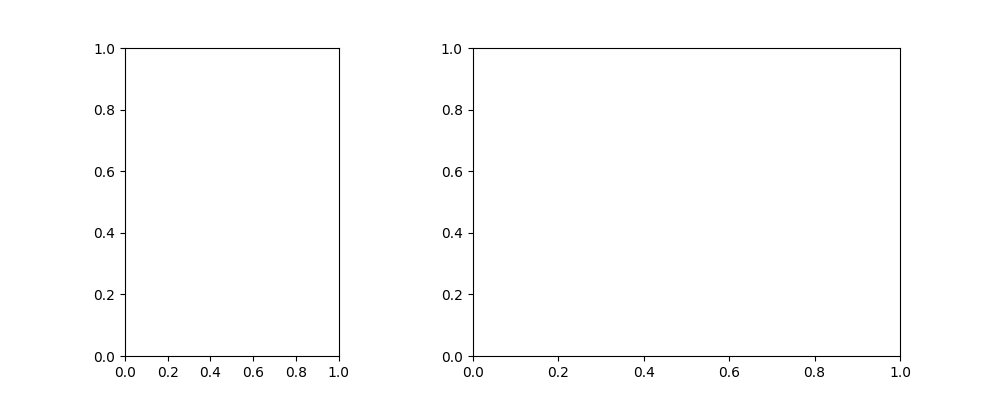

In [16]:
import matplotlib.gridspec as gridspec

"""
# dynamics and strong seasonal cycle, but no Landsat.
basin = 'USGS-13013650'
start_date = np.datetime64('1995-01-01')
end_date = np.datetime64('1999-07-01')
y_max = 100000
log = True

basin = 'USGS-04183500'
start_date = np.datetime64('2017-01-01')
end_date = np.datetime64('2017-07-01')
y_max = 50000
log = False
"""

basin = 'USGS-06934500'
start_date = np.datetime64('2017-01-01')
end_date = np.datetime64('2021-07-01')
y_max = 1000000
log = False

# Plot the true values and predictions
plt.close('all')

# Create a figure
fig = plt.figure(figsize=(10, 4))

# Create a GridSpec with 1 row and 3 columns
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.2, 2])
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 2])]

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

legend_elements = []
mins, maxs = [], []
for preds, name, (c, s) in zip(predict_results, exp_names, line_styles):
    if s == '--':
        continue
    
    basin_mask  = preds.index.get_level_values('basin') == basin
    sorted_df = preds[basin_mask].sort_values('date')
    
    date = sorted_df.index.get_level_values('date')
    values = sorted_df['pred']['flux'].values
    obs = sorted_df['obs']['flux'].values
     
    if not 'era5' in preds['dt'].columns:
        #Remove the predictions with no query basis
        mask = sorted_df['dt']['landsat'] == 0
        masked_date = date[mask]
        masked_values = values[mask]
        masked_obs = obs[mask]
        axes[0].scatter(masked_obs, masked_values, 15, marker='s',color=c)
        axes[1].plot(date, values, linewidth=1, color=c, label=name)#, facecolor='none')
        l = axes[1].scatter(masked_date, masked_values, 15, marker='s', color=c, label=name)#, facecolor='none')
        legend_elements.append(l)
    else:
        axes[0].scatter(obs, values, 15, marker='o',color=c)
        l = axes[1].plot(date, values, color=c, label=name)
        legend_elements.append(l[0])
    
    mins.extend([np.nanmin(values), np.nanmin(obs)])
    maxs.extend([np.nanmax(values), np.nanmax(obs)])
    
    
l = axes[1].scatter(date, obs, color='k', zorder=10, label='Observations')
legend_elements.append(l)

min_val = float(np.min(mins))*0.9
max_val = float(np.max(maxs))*1.1
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--')

# Setting axes to be square and equal range
axes[0].axis('square')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].set_xlabel(f"Observed SSF (T/day)")
axes[0].set_ylabel(f"Predicted SSF (T/day)")
axes[1].set_title(f"Basin: {basin}", loc='left')

axes[1].set_xlim(start_date, end_date)
axes[1].set_ylim(1, y_max)
axes[1].set_ylabel("SSF (T/day)")
if log:
    axes[1].set_yscale('log')

fig.subplots_adjust(top=0.85, left=0.06, right=0.8, wspace=0.1, hspace=0.4)
fig.autofmt_xdate()


fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.8, 0.5))


plt.show()

fig.savefig(fig_dir / f"{basin}_zoom_timeseries.png",  dpi=300)

In [12]:
face_colors

['#d95f02', '#d95f0250', '#7570b3', '#7570b350', '#1b9e77', '#1b9e7750']

In [ ]:
avg_dt = results[0]['dt']['landsat'].groupby(level='basin').mean().values
RE_change = (basin_metrics[0]['flux']['RE']- basin_metrics[2]['flux']['RE']).values.astype(float)

In [ ]:
results[0]

In [ ]:
plt.close('all')
plt.scatter(avg_dt,np.sign(RE_change))

In [ ]:
basin_metrics[0]['flux']['RE'].values.astype(float)

In [ ]:
np.sign(RE_change)

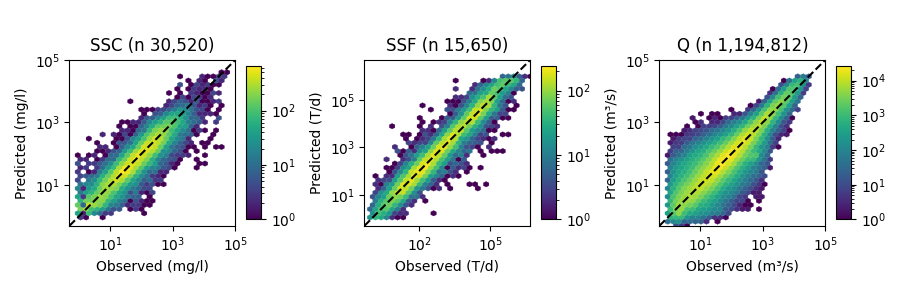

In [15]:
def hexbin_1to1(ax, x, y, target, target_label, max_val, unit):
    positive_mask = (x > 0) & (y > 0)
    x = x[positive_mask]
    y = y[positive_mask]

    min_val = 5E-1
    log_min = np.log10(min_val)
    log_max = np.log10(max_val)

    hb = ax.hexbin(x, y, gridsize=(30,20), bins='log', mincnt=1,
                linewidth=0.2,
                extent=(log_min, log_max, log_min, log_max),
                xscale='log', yscale='log')
    plt.colorbar(hb, shrink=0.6, aspect=10, anchor=(0,0.5))

    # Add a 1:1 line over the min and max of x and y
    ax.plot([min_val, max_val], [min_val, max_val], 'k--')

    # Setting axes to be square and equal range
    ax.axis('square')
    ax.set_xlim(min_val, max_lim)
    ax.set_ylim(min_val, max_lim)
    ax.set_title(f"{target_label} (n {len(x):,})")
    ax.set_xlabel(f'Observed ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')

    

targets = ['ssc','flux','usgs_q']
target_labels = ['SSC', 'SSF', 'Q']
units = ['mg/l', 'T/d', 'm³/s']
max_lims = [1E5, 5E6, 1E5]

fig, axes = plt.subplots(1,len(targets), figsize=(len(targets)*3, 3))

idx_plot = 0
axes = [axes] if len(targets)==1 else axes        
for target, target_label, unit, max_lim, ax in zip(targets, target_labels, units, max_lims, axes):
    dt_mask = results[idx_plot]['dt'].max(axis=1) >= 0
    x = results[idx_plot]['obs'][target]
    y = results[idx_plot]['pred'][target]
    hexbin_1to1(ax, x[dt_mask], y[dt_mask], target, target_label, max_lim, unit)


plt.tight_layout()

fig.savefig(fig_dir / f"bulk_scatterplots.png", dpi=300)

In [ ]:
bulk_metrics[0]

In [ ]:
import sklearn.metrics as skm

def get_log_r2(df, target):
    x = df['obs'][target]
    y = df['pred'][target]
    positive_mask = (x > 0) & (y > 0)
    x = x[positive_mask]
    y = y[positive_mask]
    
    if len(x) > 10:
        return skm.r2_score(np.log10(x),np.log10(y))
    else:
        return np.nan
    
for target in ['ssc','flux','usgs_q']:
    r2 = results[0].groupby(level='basin').apply(get_log_r2, target)
    print(f"{target}: {r2.median()}")

In [ ]:
basin_metrics[0]['flux']

In [ ]:
import evaluate
evaluate.get_all_metrics(results[0][dt_mask])

In [ ]:
cfg = {'step_kwargs':{'aaa':1, 'bbb':2}}
cfg.get('target_weights',{}).get('ssc', 1)

In [ ]:
matchups

In [ ]:
plt.close('all')
sites[metric].hist()

In [ ]:
from matplotlib.colors import Normalize


sites = pd.read_csv('/work/pi_kandread_umass_edu/tss-ml/data/NA_WQP/preprocess/hydrography_matchups.csv',index_col='wqp_id')
geom = gpd.GeoSeries.from_wkt(sites.geometry)
sites = gpd.GeoDataFrame(sites, geometry = geom)

var = 'flux'
metric = 'RE'

sites = sites.merge(basin_metrics[0][var][metric], left_index=True, right_index=True)
sites[metric] = sites[metric].astype(float)

plt.close('all')

# Create a plot with GeoPandas
fig, ax = plt.subplots(figsize=(8, 3))

# Define the normalization from -1 to 1
# norm = Normalize(vmin=-1, vmax=1)
# cmap = 'RdYlBu'

norm = Normalize(vmin=0, vmax=400)
cmap = 'inferno'

# Plot the data, specifying 'KGE' as the column, and applying the colormap and normalization
sites.plot(column=metric, cmap=cmap, norm=norm, markersize=20, ax=ax)

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Empty array to avoid warnings
cbar = fig.colorbar(sm, ax=ax)

# Optional: Set colorbar label
cbar.set_label(f'{metric} Values', fontsize=12)

plt.show()